min: 104
max: 255
mean: 250.3067787247475
Saved: output_images/raw_image.png


/tmp/ipykernel_15591/4207653634.py:32: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(array, mode='L')


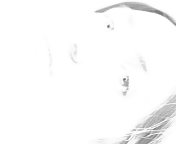

Saved: output_images/stretched_image.png


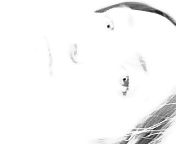

In [ ]:
#GRAYSCALE
import numpy as np
from PIL import Image
import os

# image size
image_width = 176
image_height = 144

# files
hex_file_path = './hex_data.txt'
output_folder = 'output_images'
raw_output_filename = 'raw_image.png'
stretched_output_filename = 'stretched_image.png'

def load_hex_image(file_path, width, height):
    with open(file_path, 'r') as file:
        hex_data = file.read().replace(' ', '').replace('\n', '')

    raw_data = bytes.fromhex(hex_data)
    pixels = np.frombuffer(raw_data, dtype=np.uint8)

    expected_pixels = width * height
    if pixels.size != expected_pixels:
        raise ValueError(f"Expected {expected_pixels} pixels, got {pixels.size}")

    return pixels.reshape((height, width))

def save_image(array, folder, filename):
    os.makedirs(folder, exist_ok=True)
    path = os.path.join(folder, filename)
    img = Image.fromarray(array, mode='L')
    img.save(path)
    print(f"Saved: {path}")
    return img

# load image
image_array = load_hex_image(hex_file_path, image_width, image_height)

# stats
print("min:", image_array.min())
print("max:", image_array.max())
print("mean:", image_array.mean())

# save raw image
raw_img = save_image(image_array, output_folder, raw_output_filename)
display(raw_img)

# contrast-stretched version for visibility
min_val = image_array.min()
max_val = image_array.max()

if max_val > min_val:
    stretched = ((image_array - min_val) / (max_val - min_val) * 255).astype(np.uint8)
else:
    stretched = image_array.copy()

stretched_img = save_image(stretched, output_folder, stretched_output_filename)
display(stretched_img)